# Regime comparison on the real guided sampler (04-style)

Runs actual guided reverse sampling (not just the static 1D energy slice from `05`) for the four
prior regimes from the report, at the tuned parameters found there, on the trained toy-manifold
score net:

- **basic**: no prior.
- **v1** (bootstrap): `dirichlet_alpha=0.25`, `B=256`.
- **v2** (closed-form): `lambda=0.95` at `kappa=10` (solved to `alpha_0 = kappa*(1-lambda)/(k*lambda)`
  at the production `k=3`).
- **v2-distance** (distance-gated, prototype from `05`): `ell=0.15` at `alpha_0_base=1`, `kappa=100`.

All four share the same guidance schedule (`eta=1.0` relative trust region, `window=(0.5,1.0)`,
`k_neighbors=3`) so only the regularization differs between panels. An
**unguided** baseline (no Fisher-Rao term at all) is shown first as a single panel, then two
figures: unprojected (ambient) guidance and tangent-projected guidance, each a 2x2 grid of scatter
plots, one panel per regime.

In [11]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr, bayesian_fr, bayesian_fr_v2
from guidance.driver import apply_projector

REGIME = "normal"
N = int(os.environ.get("N_DATA", 20))
TAG = f"{REGIME}_N{N}"
ckpt = torch.load(f"checkpoints/score_{TAG}.pt", weights_only=False)
train_config = ckpt["config"]
d, device = train_config["d"], train_config["device"]
X_target = ckpt["X_target"].to(device)
u_target = ckpt["u_target"].to(device)

print(f"regime={REGIME} N={N} d={d} device={device} N_data={X_target.shape[0]}")

regime=normal N=20 d=2 device=cpu N_data=20


In [12]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, train_config["hidden"], train_config["depth"]).to(device)
net.load_state_dict(ckpt["net_state"])
net.eval()
print("Loaded score net.")

Loaded score net.


In [13]:
config = {
    "beta_min": train_config["beta_min"], "beta_max": train_config["beta_max"], "T": train_config["T"],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 5,
    "ell": 1,                        # guidance PERIOD (apply every step) -- unrelated to the
                                      # distance-gate length scale below, which is named GATE_ELL
    "mem_dist_threshold": 0.05,      # a sample counts as memorized if it lands within this
                                      # Euclidean distance of any training atom
    "eta": 0.5,                      # relative trust region: correction = eta * ||base step|| * grad/||grad||
    "window": (0.5, 1),
    # NOTE: BETA_FLOOR below still feeds the v1/v2/v2_gated regularized variants (their own,
    # independent scalar-floor mechanism) -- "basic" now uses basic_fr's untempered default.
    "beta_floor": 1,
}

# tuned parameters from the report / 05 notebook
V1_DIRICHLET_ALPHA, V1_B = 0.25, 256
V2_LAMBDA, V2_KAPPA = 0.95, 10.0
V2_ALPHA0 = V2_KAPPA * (1 - V2_LAMBDA) / (config["k_neighbors"] * V2_LAMBDA)
GATE_ELL, GATE_ALPHA0_BASE, GATE_KAPPA = 0.5, 0.2, 10.0

print(f"v2: lambda={V2_LAMBDA} -> alpha_0={V2_ALPHA0:.5f} (kappa={V2_KAPPA}, k={config['k_neighbors']})")
print(f"v2-gated: ell={GATE_ELL}, alpha_0_base={GATE_ALPHA0_BASE}, kappa={GATE_KAPPA}")

def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1 - alpha_bar(t)).clamp(min=1e-4)

v2: lambda=0.95 -> alpha_0=0.10526 (kappa=10.0, k=5)
v2-gated: ell=0.5, alpha_0_base=0.2, kappa=10.0


In [14]:
n_steps = config["n_steps"]
dt = config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()



In [15]:
index = basic_fr.build_flat_index(X_target)
K = config["k_neighbors"]
BETA_FLOOR = config["beta_floor"]

def beta_t_fn():
    return sigma2(t_vec_holder["t"])

def gated_fisher_rao_energy_v2(y, neighbors, beta_t, alpha0, kappa, P=None, beta_floor=None):
    """Same closed-form v2 formula as bayesian_fr_v2.fisher_rao_energy_v2, but alpha0 is a
    per-sample tensor [B] instead of a scalar (the library function can't take a tensor alpha_0 --
    see 05's writeup). alpha0(y) = GATE_ALPHA0_BASE * exp(-d_min(y)^2 / (2*GATE_ELL^2))."""
    k = neighbors.shape[1]
    beta_col = beta_t.view(-1, 1)
    beta_soft_col = beta_col if beta_floor is None else beta_col.clamp(min=beta_floor)
    g = y.unsqueeze(1) - neighbors
    E = 0.5 * (g ** 2).sum(-1)
    q = torch.softmax(-E / beta_soft_col, dim=-1)
    a0 = k * alpha0 + kappa                                    # [B]
    q_bar = (alpha0.unsqueeze(-1) + kappa * q) / a0.unsqueeze(-1)  # [B, k]
    if P is not None:
        g = apply_projector(P, g)
    Eq_g = (q_bar.unsqueeze(-1) * g).sum(1)
    Eq_g2 = (q_bar * (g ** 2).sum(-1)).sum(1)
    I_qbar = (Eq_g2 - (Eq_g ** 2).sum(-1)) / beta_t ** 2
    return (a0 / (a0 + 1)) * I_qbar, q_bar, g

def d_min_of(y):
    return torch.cdist(y, index).min(1).values

def make_v2_gated_energy_fn():
    def energy_fn(y):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, K)
        beta_t = beta_t_fn()
        alpha0 = GATE_ALPHA0_BASE * torch.exp(-d_min_of(y) ** 2 / (2 * GATE_ELL ** 2))
        E, _, _ = gated_fisher_rao_energy_v2(y, neighbors, beta_t, alpha0, GATE_KAPPA, beta_floor=BETA_FLOOR)
        return E
    return energy_fn

def make_v2_gated_projected_energy_fn():
    def energy_fn(y, P):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, K)
        beta_t = beta_t_fn()
        alpha0 = GATE_ALPHA0_BASE * torch.exp(-d_min_of(y) ** 2 / (2 * GATE_ELL ** 2))
        E, _, _ = gated_fisher_rao_energy_v2(y, neighbors, beta_t, alpha0, GATE_KAPPA, P=P, beta_floor=BETA_FLOOR)
        return E
    return energy_fn

ENERGY_FNS = {
    "basic": basic_fr.make_knn_fr_energy_fn(index, K, beta_t_fn),
    "v1": bayesian_fr.make_knn_bayesian_fr_energy_fn(index, K, beta_t_fn, B=V1_B,
                                                      dirichlet_alpha=V1_DIRICHLET_ALPHA, beta_floor=BETA_FLOOR),
    "v2": bayesian_fr_v2.make_knn_bayesian_v2_fr_energy_fn(index, K, beta_t_fn, alpha_0=V2_ALPHA0,
                                                            kappa=V2_KAPPA, beta_floor=BETA_FLOOR),
    "v2_gated": make_v2_gated_energy_fn(),
}
PROJECTED_ENERGY_FNS = {
    "basic": basic_fr.make_knn_projected_energy_fn(index, K, beta_t_fn),
    "v1": bayesian_fr.make_knn_bayesian_projected_energy_fn(index, K, beta_t_fn, B=V1_B,
                                                             dirichlet_alpha=V1_DIRICHLET_ALPHA, beta_floor=BETA_FLOOR),
    "v2": bayesian_fr_v2.make_knn_bayesian_v2_projected_energy_fn(index, K, beta_t_fn, alpha_0=V2_ALPHA0,
                                                                   kappa=V2_KAPPA, beta_floor=BETA_FLOOR),
    "v2_gated": make_v2_gated_projected_energy_fn(),
}
METHOD_LABELS = {
    "basic": "basic (no prior)",
    "v1": fr"v1 bootstrap ($\alpha_D$={V1_DIRICHLET_ALPHA:g}, B={V1_B})",
    "v2": fr"v2 closed-form ($\lambda$={V2_LAMBDA:g}, $\alpha_0$={V2_ALPHA0:.3f}, $\kappa$={V2_KAPPA:g})",
    "v2_gated": fr"v2-distance ($\ell$={GATE_ELL:g}, $\alpha_0^{{base}}$={GATE_ALPHA0_BASE:g}, $\kappa$={GATE_KAPPA:g})",
}
print("energy fns ready:", list(ENERGY_FNS))

energy fns ready: ['basic', 'v1', 'v2', 'v2_gated']


In [16]:
def tangent_vec_from_u(u):
    t = torch.stack([torch.ones_like(u), 1.2 * torch.cos(2 * u)], dim=-1)
    return t / t.norm(dim=-1, keepdim=True)

def analytic_tangent_projector(y):
    u = y[:, 0].clamp(-3.2, 3.2)
    t = tangent_vec_from_u(u)
    return torch.einsum("bi,bj->bij", t, t)

def _y_fn_single(z_i, t_i):
    eps_hat = net(z_i[None], t_i[None])
    a = alpha_bar(t_i[None])
    return ((z_i[None] - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt())[0]

_denoiser_jacobian_fn_raw = torch.func.vmap(torch.func.jacrev(_y_fn_single))

def denoiser_jacobian_fn(z_t):
    t_vec = t_vec_holder["t"]
    return _denoiser_jacobian_fn_raw(z_t, t_vec).detach()

def make_guidance_fn(method, jacobian_name):
    if jacobian_name == "unprojected":
        return driver.make_autograd_guidance_fn(y_fn, ENERGY_FNS[method], target_range=None)
    return driver.make_projected_guidance_fn(
        y_fn, PROJECTED_ENERGY_FNS[method], analytic_tangent_projector, target_range=None,
        denoiser_jacobian_fn=denoiser_jacobian_fn)

In [17]:
u_scan = torch.linspace(-4.0, 4.0, 4000, device=device)
curve_scan = torch.stack([u_scan, 0.6 * torch.sin(2 * u_scan)], dim=-1)

def dist_to_manifold(X):
    return torch.cdist(X, curve_scan).min(dim=1).values

def is_memorized(X, atoms, thresh):
    d_min = torch.cdist(X, atoms).min(dim=1).values
    return d_min.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_dist_threshold"])
    unmem = ~mem
    fidelity = dist_to_manifold(X[unmem]).pow(2).mean().item() if unmem.any() else float("nan")
    return {"mem_ratio": mem.float().mean().item(), "fidelity_mse": fidelity}

def run_condition(guidance_fn, eta, window):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        return x.detach()
    progress_lo, progress_hi = window
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], trust_region=eta)
    return z_final.detach()

unguided     mem_ratio=0.505 fidelity_mse=0.001306
Saved -> regime_comparison_unguided.png


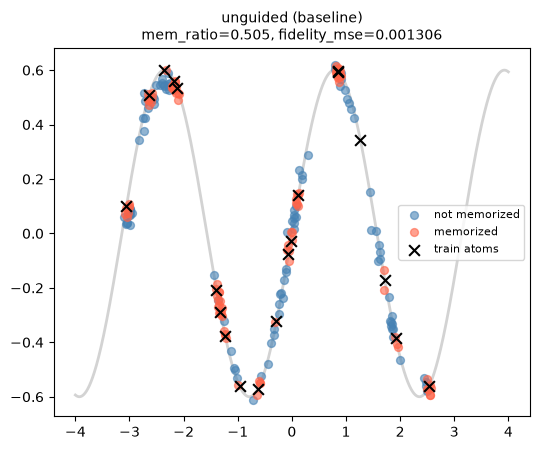

In [18]:
X_unguided = run_condition(None, config["eta"], config["window"])
unguided_metrics = evaluate(X_unguided)
print(f"unguided     mem_ratio={unguided_metrics['mem_ratio']:.3f} "
      f"fidelity_mse={unguided_metrics['fidelity_mse']:.4g}")

fig, ax = plt.subplots(figsize=(5.5, 4.6))
mem = is_memorized(X_unguided, X_target, config["mem_dist_threshold"])
ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="lightgray", lw=2, zorder=0)
ax.scatter(X_unguided[~mem, 0].cpu(), X_unguided[~mem, 1].cpu(), s=32, color="steelblue", alpha=0.6,
           label="not memorized", zorder=1)
ax.scatter(X_unguided[mem, 0].cpu(), X_unguided[mem, 1].cpu(), s=32, color="tomato", alpha=0.6,
           label="memorized", zorder=2)
ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=60, color="black", marker="x",
           label="train atoms", zorder=3)
ax.set_title(f"unguided (baseline)\nmem_ratio={unguided_metrics['mem_ratio']:.3f}, "
             f"fidelity_mse={unguided_metrics['fidelity_mse']:.4g}", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("regime_comparison_unguided.png", dpi=130)
print("Saved -> regime_comparison_unguided.png")
plt.show()

In [19]:
METHODS = ["basic", "v1", "v2", "v2_gated"]
JACOBIANS = ["unprojected", "projected"]

results = {}
for jacobian_name in JACOBIANS:
    for method in METHODS:
        guidance_fn = make_guidance_fn(method, jacobian_name)
        X = run_condition(guidance_fn, config["eta"], config["window"])
        metrics = evaluate(X)
        results[(jacobian_name, method)] = (X, metrics)
        print(f"{jacobian_name:12s} {method:10s} mem_ratio={metrics['mem_ratio']:.3f} "
              f"fidelity_mse={metrics['fidelity_mse']:.4g}")

unprojected  basic      mem_ratio=0.055 fidelity_mse=0.005783
unprojected  v1         mem_ratio=0.000 fidelity_mse=0.003931
unprojected  v2         mem_ratio=0.010 fidelity_mse=0.006426
unprojected  v2_gated   mem_ratio=0.010 fidelity_mse=0.004426
projected    basic      mem_ratio=0.020 fidelity_mse=0.0005687
projected    v1         mem_ratio=0.005 fidelity_mse=0.003096
projected    v2         mem_ratio=0.010 fidelity_mse=0.006412
projected    v2_gated   mem_ratio=0.005 fidelity_mse=0.002472


Saved -> regime_comparison_unprojected.png


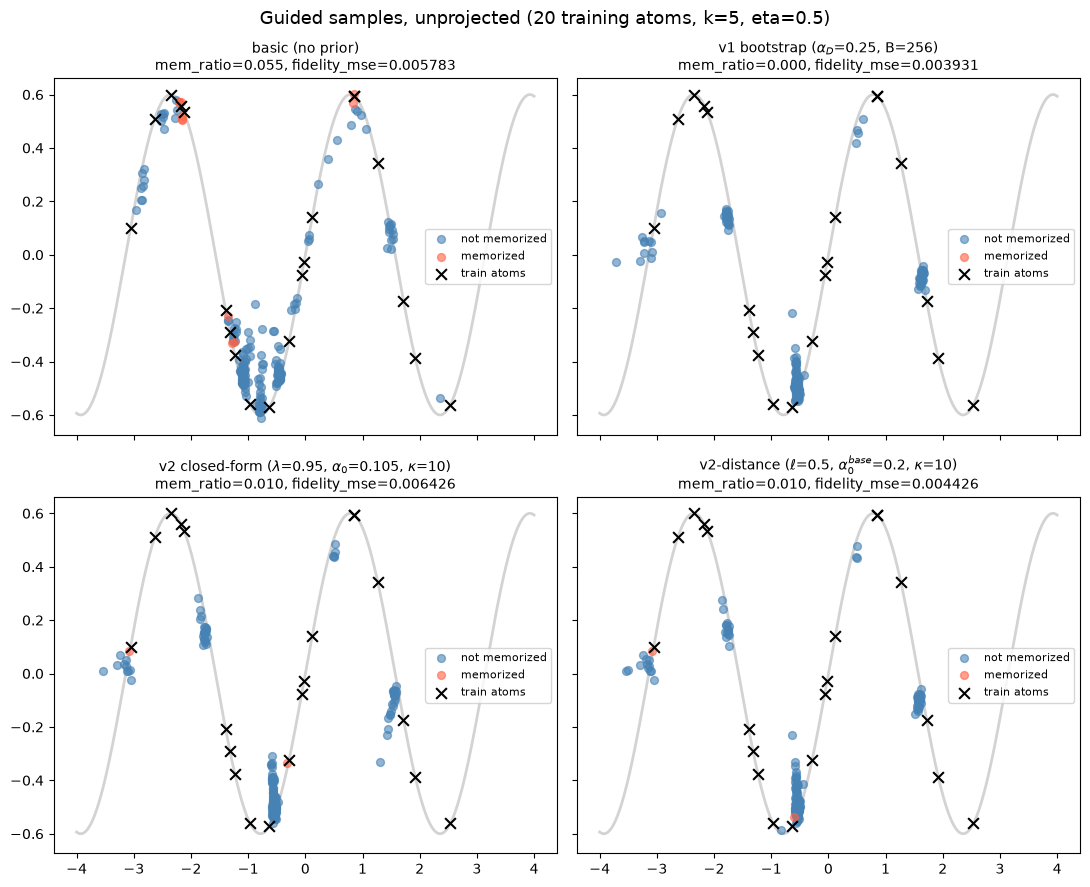

Saved -> regime_comparison_projected.png


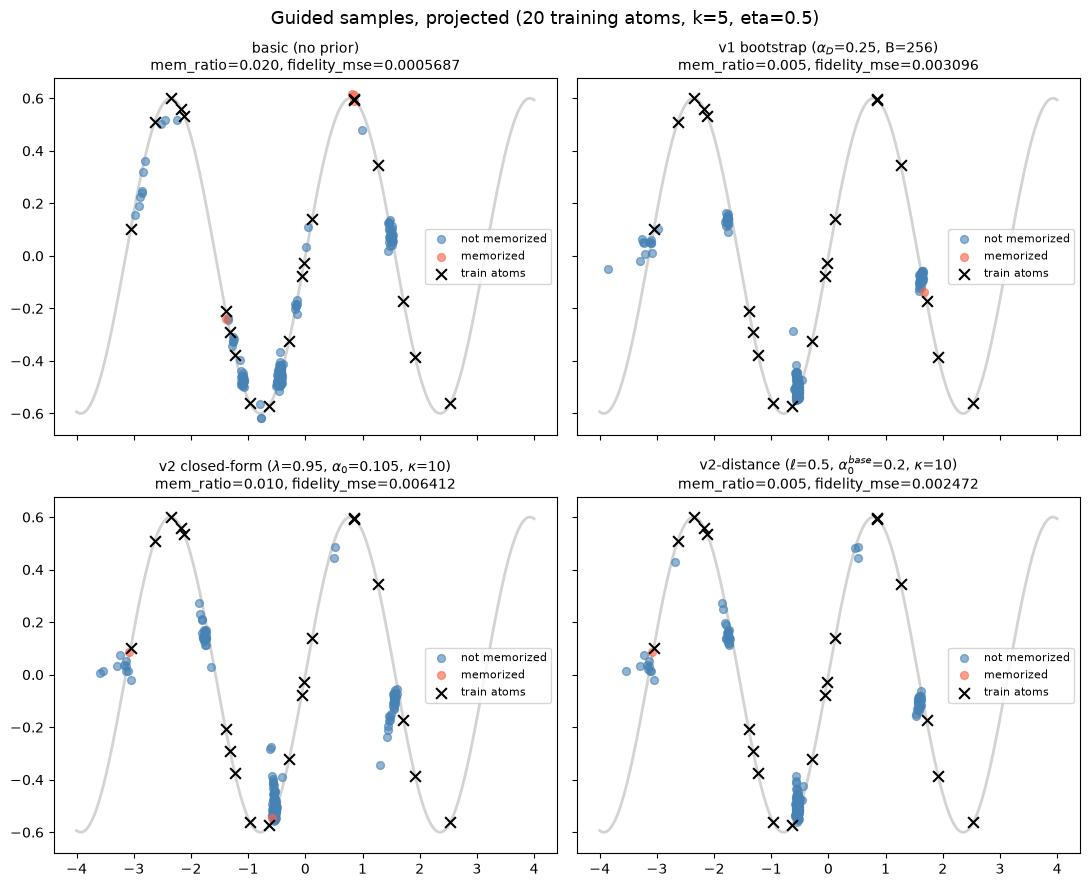

In [20]:
def plot_grid(jacobian_name, save_name):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
    for ax, method in zip(axes.flat, METHODS):
        X, metrics = results[(jacobian_name, method)]
        mem = is_memorized(X, X_target, config["mem_dist_threshold"])
        ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="lightgray", lw=2, zorder=0)
        ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=32, color="steelblue", alpha=0.6,
                   label="not memorized", zorder=1)
        ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=32, color="tomato", alpha=0.6,
                   label="memorized", zorder=2)
        ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=60, color="black", marker="x",
                   label="train atoms", zorder=3)
        ax.set_title(f"{METHOD_LABELS[method]}\nmem_ratio={metrics['mem_ratio']:.3f}, "
                     f"fidelity_mse={metrics['fidelity_mse']:.4g}", fontsize=10)
        ax.legend(fontsize=8)
    fig.suptitle(f"Guided samples, {jacobian_name} ({N} training atoms, k={K}, eta={config['eta']})",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(save_name, dpi=130)
    print(f"Saved -> {save_name}")
    plt.show()

plot_grid("unprojected", "regime_comparison_unprojected.png")
plot_grid("projected", "regime_comparison_projected.png")